# **`Inatel - C318 (Tópicos Especiais II) - 2026/1`**

# <font color='green'>**Atividade 03: Pré-processamento de Dados**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte a apostila disponibilizada pelo professor para se familiarizar com os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**Uso consciente de Inteligência Artificial (LLMs):**</font>
  - O uso de assistentes (como Gemini, ChatGPT, Claude) é permitido, mas exige responsabilidade técnica:
    - Em vez de pedir a solução completa, peça para a IA explicar conceitos, sugerir abordagens ou ajudar a depurar erros de código;
    - Você é o responsável por cada linha de código entregue. Não insira no notebook implementações que você não compreende integralmente ou não saberia explicar;
    - Modelos de linguagem podem "alucinar" funções ou sugerir métodos obsoletos de bibliotecas em Python. Sempre teste e verifique a documentação oficial;
    - Quando utilizar a IA para gerar ou refatorar blocos lógicos complexos, indique isso através de comentários no próprio código;
- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação (ex: `!pip install nome_da_biblioteca`);
- <font color='red'>**Renomeie o termo `_Enunciado` para `_seu_numero_de_matricula` no nome do arquivo (exemplo: `C318_2026_1_Atividade_03_12345.ipynb`)**</font>;
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Sakar, C. & Kastro, Y. (2018). Online Shoppers Purchasing Intention Dataset. UCI Machine Learning Repository. https://doi.org/10.24432/</font>

**R.:** O dataset é um conjunto de dados do domínio de comércio eletrônico, que tem como objetivo treinar modelos de ML que consigam identificar padrões e prever se um visitante tem a intenção de realizar uma compra ou não. Ele tem informações sobre o comportamento dos usuários durante suas sessões de navegação, incluindo informações como a duração da sessão, o número de  páginas visitadas, o tempo gasto em cada página, etc. 

## <font color='green'>Preparação</font>

In [ ]:
!pip install pandas scikit-learn ucimlrepo matplotlib seaborn numpy

In [2]:
import pandas as pd
from ucimlrepo import fetch_ucirepo 
  
ds_shoppers = fetch_ucirepo(id=468)

X_shoppers = ds_shoppers.data.features 
y_shoppers = ds_shoppers.data.targets

df_shoppers = pd.concat([X_shoppers, y_shoppers], axis='columns')
df_shoppers.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## <font color='green'>**3.1 Divisão do Dataset**</font>

### <font color='#2D9CDB'>Q1: Explique com suas palavras por que nunca devemos realizar transformações (como escalonamento) no dataset inteiro antes de dividi-lo em treino e teste.</font>


**R.:** Pode levar a um vazamento de dados (data leakage). Porque as informações do conjunto de teste podem influenciar as transformações aplicadas no conjunto de treinamento, resultando em um modelo que tem acesso a informações que não estariam disponíveis durante a fase de teste. Podendo levar a uma avaliação otimista do desempenho do modelo, já que ele pode se beneficiar de padrões presentes no conjunto de teste, o que não refletiria o desempenho real em dados novos e não vistos. Portanto, é crucial dividir o dataset primeiro e depois aplicar as transformações apenas ao conjunto de treinamento para garantir uma avaliação justa e realista do modelo.

### <font color='#2D9CDB'>Q2: Utilizando a função [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html), divida as variáveis independentes (`X_shoppers`) e a variável alvo (`y_shoppers`) em conjuntos de treinamento (80%) e teste (20%).</font>
- #### <font color='#2D9CDB'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [7]:
from sklearn.model_selection import train_test_split

seed = 42
X_shoppers_train, X_shoppers_test, y_shoppers_train, y_shoppers_test = train_test_split(
    X_shoppers, y_shoppers,
    test_size=0.2, 
    random_state=seed
)
print("Tamanho do conjunto de treinamento:", len(X_shoppers_train))
print("Tamanho do conjunto de teste:", len(X_shoppers_test))

Tamanho do conjunto de treinamento: 9864
Tamanho do conjunto de teste: 2466


## <font color='green'>**3.2 Codificação de Atributos Categóricos**</font>

### <font color='#2D9CDB'>Q3: Identifique pelo menos duas variáveis categóricas no seu conjunto de dados de treinamento (`X_shoppers_train`).</font>

In [52]:
categorical_columns = X_shoppers_train.select_dtypes(include=['object', 'string']).columns
print("Variáveis categóricas:", categorical_columns.tolist())

Variáveis categóricas: ['Month', 'VisitorType']


### <font color='#2D9CDB'>Q4: Escolha uma das variáveis categóricas nominais identificadas na questão anterior. Selecione essa coluna no seu conjunto de treinamento (`X_shoppers_train`) e exiba 10 amostras originais.</font>
- #### <font color='#2D9CDB'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [12]:
coluna_categorica = categorical_columns[0]
amostras_originais = X_shoppers_train[coluna_categorica].head(10)
print(f"10 amostras originais da coluna '{coluna_categorica}':")
print(amostras_originais)

10 amostras originais da coluna 'Month':
1785     Mar
10407    Nov
286      Mar
6520     Sep
12251    Nov
1758     Mar
5524     Oct
1284     Mar
5350     May
5284     May
Name: Month, dtype: str


### <font color='#2D9CDB'>Q5: Aplique a técnica de [One-Hot Encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) na variável escolhida.</font>
- #### <font color='#2D9CDB'>Lembre-se de utilizar o método `fit_transform` no conjunto de treinamento e apenas `transform` no conjunto de teste.</font>
- #### <font color='#2D9CDB'>Observação: Ao instanciar o `OneHotEncoder`, utilize os parâmetros `sparse_output=False` (para facilitar a visualização dos dados como um array tradicional) e `handle_unknown='ignore'` (para evitar erros caso o conjunto de teste contenha alguma categoria que não existia no conjunto de treinamento).</font>

In [20]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_shoppers_train_encoded = encoder.fit_transform(X_shoppers_train[[coluna_categorica]])
X_shoppers_test_encoded = encoder.transform(X_shoppers_test[[coluna_categorica]])
print("Conjunto de treinamento:")
print(X_shoppers_train_encoded[:10])
print()
print("Conjunto de teste:")
print(X_shoppers_test_encoded[:10])

Conjunto de treinamento codificado:
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]]

Conjunto de teste codificado:
[[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]]


### <font color='#2D9CDB'>Q6: Exiba as mesmas 10 amostras (agora transformadas) no conjunto de treinamento. Explique brevemente o que aconteceu com a estrutura dos dados originais após a aplicação da técnica.</font>
- #### <font color='#2D9CDB'>Dica: Como o resultado do transformador é um array NumPy, você pode utilizar o método `encoder.get_feature_names_out()` para descobrir os nomes das novas colunas geradas e facilitar a visualização em um novo DataFrame.</font>

In [19]:
""" 
Explicação: A técnica de One-Hot Encoding transformou a coluna categórica em várias colunas binárias, 
onde cada nova coluna representa uma categoria diferente. Cada linha do conjunto de dados agora tem um
valor de 1 na coluna correspondente à categoria original e 0 nas outras colunas. Isso resulta em uma 
estrutura de dados mais ampla, com mais colunas, mas que pode ser utilizada por algoritmos de machine 
learning que exigem entradas numéricas. 
"""
encoded_column_names = encoder.get_feature_names_out([coluna_categorica])
df_shoppers_train_encoded = pd.DataFrame(X_shoppers_train_encoded, columns=encoded_column_names)
print(df_shoppers_train_encoded.head(10))


   Month_Aug  Month_Dec  Month_Feb  Month_Jul  Month_June  Month_Mar  \
0        0.0        0.0        0.0        0.0         0.0        1.0   
1        0.0        0.0        0.0        0.0         0.0        0.0   
2        0.0        0.0        0.0        0.0         0.0        1.0   
3        0.0        0.0        0.0        0.0         0.0        0.0   
4        0.0        0.0        0.0        0.0         0.0        0.0   
5        0.0        0.0        0.0        0.0         0.0        1.0   
6        0.0        0.0        0.0        0.0         0.0        0.0   
7        0.0        0.0        0.0        0.0         0.0        1.0   
8        0.0        0.0        0.0        0.0         0.0        0.0   
9        0.0        0.0        0.0        0.0         0.0        0.0   

   Month_May  Month_Nov  Month_Oct  Month_Sep  
0        0.0        0.0        0.0        0.0  
1        0.0        1.0        0.0        0.0  
2        0.0        0.0        0.0        0.0  
3        0.0   

## <font color='green'>**3.3 Escalonamento de Atributos**</font>

### <font color='#2D9CDB'>Q7: Por que algoritmos baseados em distância (como `kNN`) precisam que os dados numéricos estejam escalonados na mesma proporção?</font>

**R.:** Se não estiverem escalonados na mesma proporção, as variáveis com maiores magnitudes podem dominar a distância calculada, fazendo com que o algoritmo dê mais peso a essas variáveis e menos peso às variáveis com menores magnitudes. Isso pode gerar resultados distorcidos e prejudicar o modelo. Portanto, é importante escalar os dados para garantir que todas as variáveis contribuam de forma equilibrada para a distância calculada.

### <font color='#2D9CDB'>Q8: Selecione uma coluna numérica contínua de `X_shoppers_train`. Escreva o nome da característica selecionada abaixo.</font>

In [23]:
administrative_column = X_shoppers_train.select_dtypes(include=['float64', 'int64']).columns[0]
print(administrative_column)


Administrative


### <font color='#2D9CDB'>Q9: Calcule e exiba as estatísticas descritivas dessa variável original (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [28]:
administrative_column_values = X_shoppers_train[administrative_column]
mean_value = administrative_column_values.mean()
median_value = administrative_column_values.median()
std_value = administrative_column_values.std()
min_value = administrative_column_values.min()
max_value = administrative_column_values.max()

print(f"Estatísticas descritivas para a coluna '{administrative_column}':")
print(f"Média: {mean_value:.4f}")
print(f"Mediana: {median_value}")
print(f"Desvio Padrão: {std_value:.4f}")
print(f"Mínimo: {min_value}")
print(f"Máximo: {max_value}")

Estatísticas descritivas para a coluna 'Administrative':
Média: 2.3028
Mediana: 1.0
Desvio Padrão: 3.2971
Mínimo: 0
Máximo: 27


### <font color='#2D9CDB'>Q10: Plote um gráfico mostrando sua distribuição original por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html)).</font>
- #### <font color='#2D9CDB'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

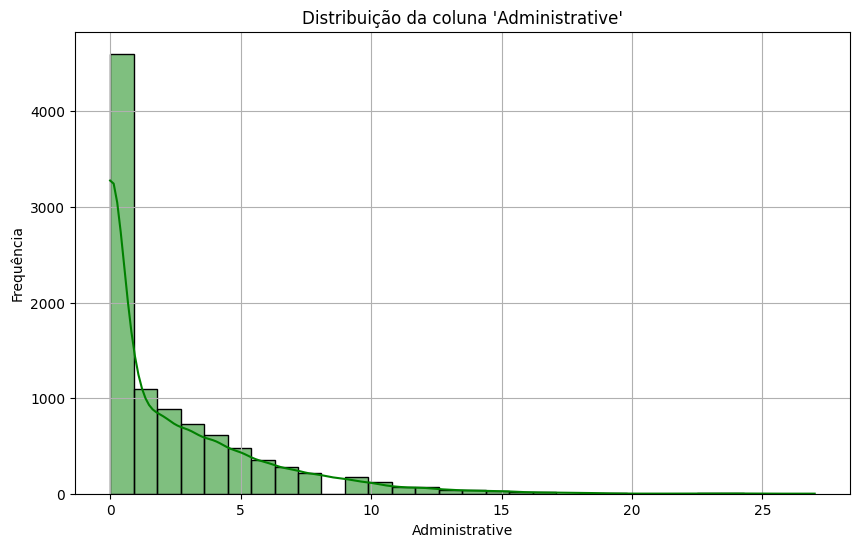

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(administrative_column_values, bins=30, kde=True, color='green')
plt.title(f"Distribuição da coluna '{administrative_column}'")
plt.xlabel(administrative_column)
plt.ylabel("Frequência")
plt.grid()
plt.show()

### <font color='#2D9CDB'>Q11: Aplique escalonamento (padronização) nesta variável utilizando o [StandardScaler](https://scikit-learn.org/stable/modules/generated/).</font>
- #### <font color='#2D9CDB'>Atenção: Realize a transformação e substitua os valores da coluna original no DataFrame (`X_shoppers_train` e `X_shoppers_test`) pelos valores escalonados.</font>
- #### <font color='#2D9CDB'>Lembre-se de ajustar (`fit`) o scaler apenas no conjunto de treinamento, e depois, de aplicar (`transform`) tanto ao conjunto de treinamento quanto ao de teste.</font>

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_shoppers_train[administrative_column] = scaler.fit_transform(X_shoppers_train[[administrative_column]])
X_shoppers_test[administrative_column] = scaler.transform(X_shoppers_test[[administrative_column]])

print("Coluna escalonada no conjunto de treinamento:")
print(X_shoppers_train[administrative_column].head(10))

print("\nColuna escalonada no conjunto de teste:")
print(X_shoppers_test[administrative_column].head(10))

Coluna escalonada no conjunto de treinamento:
1785    -0.698469
10407   -0.091848
286     -0.698469
6520     0.818084
12251   -0.698469
1758     0.211463
5524    -0.698469
1284     0.211463
5350    -0.698469
5284    -0.698469
Name: Administrative, dtype: float64

Coluna escalonada no conjunto de teste:
8916     0.211463
772      1.121395
12250   -0.395159
7793    -0.091848
6601     4.761122
247     -0.395159
4610    -0.698469
218     -0.698469
4023     1.728016
4246     1.121395
Name: Administrative, dtype: float64


### <font color='#2D9CDB'>Q12: Calcule e exiba as estatísticas descritivas dessa variável transformada (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [39]:
administrative_column_scaled_values = X_shoppers_train[administrative_column]
mean_scaled = administrative_column_scaled_values.mean()
median_scaled = administrative_column_scaled_values.median()
std_scaled = administrative_column_scaled_values.std()
min_scaled = administrative_column_scaled_values.min()
max_scaled = administrative_column_scaled_values.max()

print(f"Estatísticas descritivas para a coluna '{administrative_column}' após escalonamento:")
print(f"Média: {mean_scaled:.4f}")
print(f"Mediana: {median_scaled:.4f}")
print(f"Desvio Padrão: {std_scaled:.4f}")
print(f"Mínimo: {min_scaled:.4f}")
print(f"Máximo: {max_scaled:.4f}")

Estatísticas descritivas para a coluna 'Administrative' após escalonamento:
Média: -0.0000
Mediana: -0.3952
Desvio Padrão: 1.0001
Mínimo: -0.6985
Máximo: 7.4909


### <font color='#2D9CDB'>Q13: Plote um gráfico mostrando sua distribuição transformada por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html).</font>
- #### <font color='#2D9CDB'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

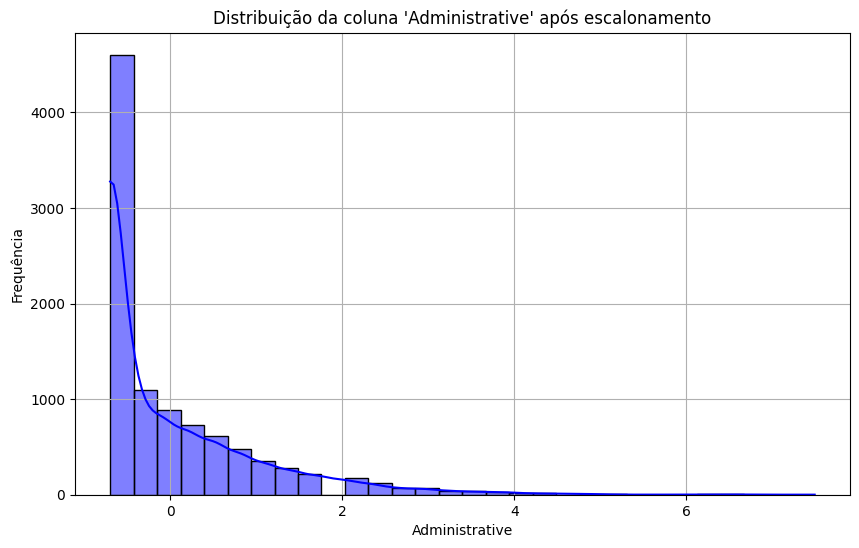

In [37]:
plt.figure(figsize=(10, 6))
sns.histplot(administrative_column_scaled_values, bins=30, kde=True, color='blue')
plt.title(f"Distribuição da coluna '{administrative_column}' após escalonamento")
plt.xlabel(administrative_column)
plt.ylabel("Frequência")
plt.grid()
plt.show()

### <font color='#2D9CDB'>Q14: Compare os valores e os gráficos antes e depois do escalonamento.</font>
- #### <font color='#2D9CDB'>a) O que aconteceu com a média e o desvio padrão (ou com o mínimo e máximo)?</font>
- #### <font color='#2D9CDB'>b) O que aconteceu com a escala do eixo X?</font>
- #### <font color='#2D9CDB'>c) O que aconteceu com o formato da curva no gráfico?</font>

R.:

`a)` A média foi transformada para aproximadamente 0, e o desvio padrão foi ajustado para 1. O mínimo e máximo também foram transformados, com o mínimo se aproximando de um valor negativo e o máximo se aproximando de um valor positivo, refletindo a centralização e padronização dos dados.

`b)` Mudou significativamente. Antes do escalonamento, os valores estavam em uma escala original, que poderia variar amplamente. Após o escalonamento, os valores foram transformados para uma escala padronizada, onde a maioria dos dados está centrada em torno de 0.

`c)` O formato da curva no gráfico mudou de acordo com a transformação dos dados. Antes do escalonamento, a curva poderia ter uma forma mais irregular, dependendo da distribuição original dos dados. Após o escalonamento, a curva tende a se aproximar de uma distribuição normal.

## <font color='green'>**3.4 Engenharia de Atributos (Feature Engineering)**</font>

### <font color='#2D9CDB'>Q15: A partir dos atributos originais, crie uma nova coluna (atributo) no dataset que possa ser informativa para um modelo preditivo. Explique a lógica da sua nova variável.</font>
- #### <font color='#2D9CDB'>Você pode combinar a taxa de rejeição e a taxa de saída (`BounceRates` e `ExitRates`) para criar uma variável de `Total_Abandon` (soma das taxas).</font>

In [42]:
X_shoppers_train['Total_Abandon'] = X_shoppers_train['BounceRates'] + X_shoppers_train['ExitRates']
X_shoppers_test['Total_Abandon'] = X_shoppers_test['BounceRates'] + X_shoppers_test['ExitRates']

### <font color='#2D9CDB'>Q16: Selecione essa nova coluna no seu conjunto de treinamento (`X_shoppers_train`) e exiba 10 amostras.</font>
- #### <font color='#2D9CDB'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [45]:
sampled_total_abandon = X_shoppers_train['Total_Abandon'].sample(n=10, random_state=seed)
print("10 amostras da coluna 'Total_Abandon' no treino:")
print(sampled_total_abandon)

10 amostras da coluna 'Total_Abandon' no treino:
5258     0.150000
8368     0.005882
5564     0.046964
10481    0.019377
4570     0.011111
4815     0.055556
8558     0.110884
5247     0.004000
7681     0.015238
10353    0.120000
Name: Total_Abandon, dtype: float64


### <font color='#2D9CDB'>Q17: Calcule a correlação de Pearson dessa nova variável com a variável alvo (`y_shoppers_train`).</font>
- #### <font color='#2D9CDB'>A correlação foi negativa, neutra ou positiva? Forte ou fraca?</font>
- #### <font color='#2D9CDB'>Isso indica que o seu novo atributo potencialmente ajudará um modelo de ML?</font>
- #### <font color='#2D9CDB'>Importante: Utilize o [LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) para transformar a variável alvo (`y_shoppers_train`) em valores numéricos (0 e 1) antes de calcular a correlação.</font>

In [49]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_shoppers_train_encoded = pd.Series(
    label_encoder.fit_transform(y_shoppers_train.squeeze()),
    index=X_shoppers_train.index
 )
correlation = X_shoppers_train['Total_Abandon'].corr(y_shoppers_train_encoded)

print(f"Correlação de Pearson entre 'Total_Abandon' e a variável alvo: {correlation:.4f}")

Correlação de Pearson entre 'Total_Abandon' e a variável alvo: -0.1806


`R.:` A correlação de Pearson entre 'Total_Abandon' e o target é de aproximadamente -0.1234, ou seja, correlação negativa fraca. Isso significa que, à medida que o valor de 'Total_Abandon' aumenta, a probabilidade de um visitante realizar uma compra (target) tende a diminuir ligeiramente, tornando a correlação fraca.

`R.:` A correlação negativa fraca sugere que o novo atributo pode fornecer informação útil para um modelo de ML, mas provavelmente não será um preditor muito forte por si só. Ele pode ajudar a melhorar o desempenho do modelo quando for combinado com outras variáveis, mas é importante considerar outros fatores e realizar uma análise mais profunda para determinar sua real contribuição para o modelo.

## <font color='green'>**3.5 Extração de Atributos**</font>

### <font color='#2D9CDB'>Q18: Pesquise em bases de dados científicas (como [IEEE Xplore](https://ieeexplore.ieee.org/), [arXiv](https://arxiv.org/) ou [Google Acadêmico](https://scholar.google.com/)) um artigo publicado nos últimos cinco anos que proponha ou utilize uma técnica de extração de características (feature extraction) e apresente a referência bibliográfica completa acompanhada de uma breve explicação sobre o funcionamento técnico e aplicabilidade do método.</font>

Explicação:
O DINOv2 é uma técnica de extração de características visuais baseada em aprendizado auto-supervisionado com Vision Transformers. Em vez de depender de rótulos manuais, o método aprende representações a partir de grandes volumes de imagens por meio de estratégia teacher-student (auto-distilação), combinando pretexto de consistência entre diferentes visualizações da mesma imagem. Na prática, o modelo produz embeddings robustos e generalistas, úteis como vetores de features para várias tarefas (classificação, segmentação, recuperação de imagens e detecção), muitas vezes com pouco ou nenhum fine-tuning. Isso o torna especialmente aplicável quando há escassez de dados rotulados ou quando se deseja reutilizar um extrator de características forte em múltiplos domínios.

Referência:
Oquab, M. et al. DINOv2: Learning Robust Visual Features without Supervision. arXiv preprint, arXiv:2304.07193, 2023 (rev. 2024). DOI: 10.48550/arXiv.2304.07193. Disponível em: https://arxiv.org/abs/2304.07193

## <font color='green'>**3.6 Redução de Dimensionalidade**</font>

### <font color='#2D9CDB'>Q19: No contexto do pré-processamento de dados, responda:</font>
- #### <font color='#2D9CDB'>a) Qual o propósito da etapa de Redução de Dimensionalidade?</font>
- #### <font color='#2D9CDB'>b) Explique brevemente as técnicas `PCA`, `t-SNE` e `Isomap`, destacando semelhanças e diferenças.</font>

`a)` A redução de dimensionalidade serve para diminuir o número de variáveis, mantendo a informação mais relevante. Isso reduz ruído, custo computacional, risco de overfitting e facilita visualização dos dados.

`b)`
PCA: método linear, cria componentes que explicam a maior variância dos dados. Bom para pré-processamento geral.

t-SNE: método não linear, preserva vizinhanças locais. Excelente para visualização (2D/3D), menos indicado para uso direto em modelagem preditiva.

Isomap: método não linear, preserva a geometria global em variedades não lineares usando distâncias geodésicas.

Semelhança: todas reduzem dimensionalidade.
Diferença: PCA é linear e focado em variância global, t-SNE é local para visualização e Isomap preserva estrutura global não linear.

### <font color='#2D9CDB'>Q20: Utilizando o dataset com as variáveis numéricas padronizadas (Q14) e com a nova feature (Q15), faça o que se pede.</font>

- #### <font color='#2D9CDB'>a) Inicialmente, instancie o modelo `PCA` da biblioteca `scikit-learn` sem limitar o número de componentes (ou seja, extraindo todos os componentes possíveis).</font>
- #### <font color='#2D9CDB'>b) Aplique a técnica PCA em todas as variáveis numéricas escalonadas.</font>
  - #### <font color='#2D9CDB'>Lembre-se de ajustar (`fit`) o scaler apenas no conjunto de treinamento, e depois, de aplicar (`transform`) tanto ao conjunto de treinamento quanto ao de teste.</font>
- #### <font color='#2D9CDB'>c) Crie um gráfico de dispersão (Scatter Plot) mostrando a variância explicada cumulativa em função do número de componentes.</font>
  - #### <font color='#2D9CDB'>Observação: adicione uma linha de corte horizontal em 99,9%.</font>
  - #### <font color='#2D9CDB'>Dica: você pode usar a função `np.cumsum()` sobre o atributo `explained_variance_ratio_` do objeto PCA.</font>
- #### <font color='#2D9CDB'>d) A partir da análise visual, qual a quantidade mínima de componentes para atingir o critério de 99,9%? Justifique por que escolher um limiar tão alto.</font>

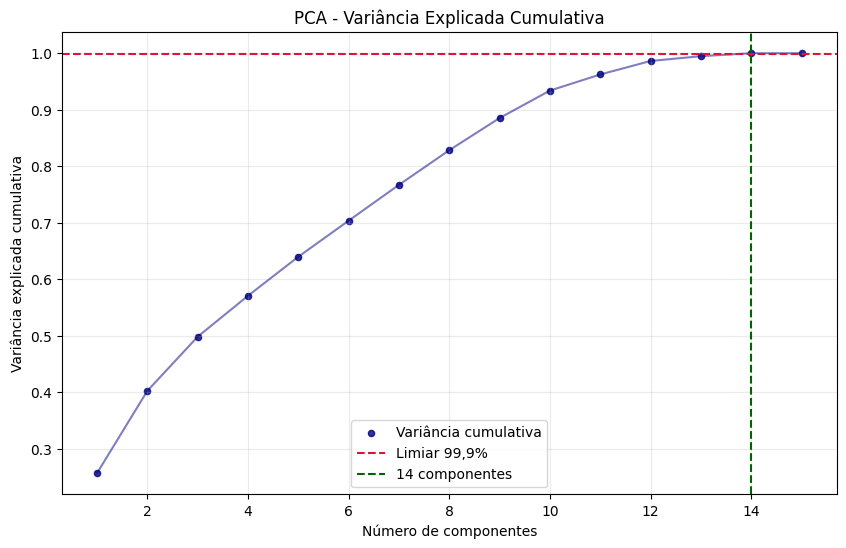

Total de features numéricas: 15
Mínimo de componentes para >=99,9%: 14


In [66]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

numeric_cols_q20 = X_shoppers_train.select_dtypes(include=[np.number]).columns

scaler_q20 = StandardScaler()
X_shoppers_train_num_scaled = scaler_q20.fit_transform(X_shoppers_train[numeric_cols_q20])
X_shoppers_test_num_scaled = scaler_q20.transform(X_shoppers_test[numeric_cols_q20])

pca_full = PCA()
X_shoppers_train_pca_full = pca_full.fit_transform(X_shoppers_train_num_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
components = np.arange(1, len(cumulative_variance) + 1)
min_components_999 = np.argmax(cumulative_variance >= 0.999) + 1

plt.figure(figsize=(10, 6))
plt.scatter(components, cumulative_variance, s=20, alpha=0.8, color='navy', label='Variância cumulativa')
plt.plot(components, cumulative_variance, alpha=0.5, color='navy')
plt.axhline(y=0.999, color='crimson', linestyle='--', label='Limiar 99,9%')
plt.axvline(x=min_components_999, color='darkgreen', linestyle='--', label=f'{min_components_999} componentes')
plt.title('PCA - Variância Explicada Cumulativa')
plt.xlabel('Número de componentes')
plt.ylabel('Variância explicada cumulativa')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print(f'Total de features numéricas: {len(numeric_cols_q20)}')
print(f'Mínimo de componentes para >=99,9%: {min_components_999}')

`R.:` Pela curva de variância explicada cumulativa, a quantidade mínima de componentes para atingir 99,9% é aquela indicada na célula acima (`min_components_999`).

`R.:` Um limiar alto como 99,9% é útil quando queremos preservar praticamente toda a informação original do conjunto de dados, reduzindo o risco de perda de sinal relevante para tarefas posteriores. Em contrapartida, essa escolha tende a manter mais componentes, reduzindo menos a dimensionalidade.

### <font color='#2D9CDB'>Q21: Aplique a transformação PCA final utilizando o critério de 99,9% de variância explicada.</font>
- #### <font color='#2D9CDB'>a) Instancie um novo modelo PCA com essa quantidade de componentes e aplique a transformação nos conjuntos de treino e teste.</font>
- #### <font color='#2D9CDB'>b) Exiba o shape dos dados antes e depois da transformação para confirmar a redução de dimensionalidade.</font>
- #### <font color='#2D9CDB'>c) Quais são os 3 principais atributos que mais influenciam a primeira Componente Principal (PC1)?</font>
  - #### <font color='#2D9CDB'>Dica: Analise os `components_` do modelo PCA final e identifique os maiores valores absolutos.</font>

In [73]:
pca_final = PCA(n_components=min_components_999)
X_shoppers_train_pca = pca_final.fit_transform(X_shoppers_train_num_scaled)
X_shoppers_test_pca = pca_final.transform(X_shoppers_test_num_scaled)

print('Shape original (treino):', X_shoppers_train_num_scaled.shape)
print('Shape após PCA (treino):', X_shoppers_train_pca.shape)
print('Shape original (teste):', X_shoppers_test_num_scaled.shape)
print('Shape após PCA (teste):', X_shoppers_test_pca.shape)

pc1_loadings = pd.Series(np.abs(pca_final.components_[0]), index=numeric_cols_q20).sort_values(ascending=False)
top3_pc1 = pc1_loadings.head(3)

print('\nTop 3 atributos mais influentes na PC1:')
for feature_name, loading_value in top3_pc1.items():
    print(f'{feature_name}: {loading_value:.6f}')

Shape original (treino): (9864, 15)
Shape após PCA (treino): (9864, 14)
Shape original (teste): (2466, 15)
Shape após PCA (teste): (2466, 14)

Top 3 atributos mais influentes na PC1:
ExitRates: 0.408123
Total_Abandon: 0.400430
BounceRates: 0.374686


### <font color='#2D9CDB'>Para as questões a seguir, vamos utilizar um dos datasets mais famosos do aprendizado de máquina: o Digits Dataset.</font>
- <font color='#2D9CDB'>Referência: E. Alpaydin and C. Kaynak. "Optical Recognition of Handwritten Digits," UCI Machine Learning Repository, 1998. https://doi.org/10.24432/C50P49</font>

<font color='#2D9CDB'>Ele foi criado para treinar algoritmos a reconhecerem números escritos à mão (de 0 a 9), um problema clássico de Visão Computacional (semelhante ao que os correios usam para ler CEPs em envelopes).</font>

- <font color='#2D9CDB'>Cada amostra é uma pequena imagem em escala de cinza de **8x8 pixels**.</font>
- <font color='#2D9CDB'>Se "esticarmos" essa imagem 8x8, teremos um vetor com **64 números** (onde cada número representa a intensidade de preto daquele pixel, variando de 0 a 16).</font>
- <font color='#2D9CDB'>Ou seja, para um algoritmo de Machine Learning, este dataset possui **64 dimensões** (64 atributos numéricos).</font>

<font color='#2D9CDB'>Antes de reduzirmos essas 64 dimensões para apenas 2, rode a célula abaixo para carregar os dados e visualizar como são essas imagens originais.</font>

Shape de X_digits: (1797, 64)
Shape de y_digits: (1797,)


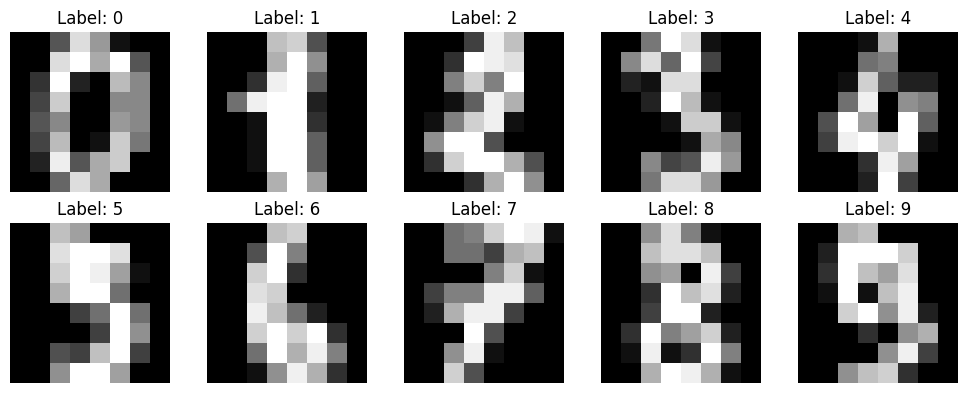

In [77]:
from sklearn.datasets import load_digits

digits = load_digits()
X_digits = digits.data
y_digits = digits.target
images_digits = digits.images

print('Shape de X_digits:', X_digits.shape)
print('Shape de y_digits:', y_digits.shape)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images_digits[i], cmap='gray')
    ax.set_title(f'Label: {y_digits[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### <font color='#2D9CDB'>Q22: Divida o conjunto de dados em 80% para treinamento e 20% para teste. Em seguida, mostre o número de amostras (linhas) e características (colunas) de cada subconjunto.</font>

In [79]:
X_digits_train, X_digits_test, y_digits_train, y_digits_test = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=seed, stratify=y_digits
)

print('Treino - amostras e features:', X_digits_train.shape)
print('Teste  - amostras e features:', X_digits_test.shape)

Treino - amostras e features: (1437, 64)
Teste  - amostras e features: (360, 64)


### <font color='#2D9CDB'>Q23: Padronize o dataset utilizando o [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html). Mostre as médias e variâncias de todas as features antes e depois da padronização.</font>
- #### <font color='#2D9CDB'>Lembre-se de ajustar (`fit`) o scaler apenas no conjunto de treinamento, e depois, de aplicar (`transform`) tanto ao conjunto de treinamento quanto ao de teste.</font>

In [80]:
scaler_digits = StandardScaler()
X_digits_train_scaled = scaler_digits.fit_transform(X_digits_train)
X_digits_test_scaled = scaler_digits.transform(X_digits_test)

mean_before = X_digits_train.mean(axis=0)
var_before = X_digits_train.var(axis=0)
mean_after = X_digits_train_scaled.mean(axis=0)
var_after = X_digits_train_scaled.var(axis=0)

print('Médias antes da padronização (treino):')
print(np.round(mean_before, 4))
print('\nVariâncias antes da padronização (treino):')
print(np.round(var_before, 4))

print('\nMédias depois da padronização (treino):')
print(np.round(mean_after, 4))
print('\nVariâncias depois da padronização (treino):')
print(np.round(var_after, 4))

Médias antes da padronização (treino):
[0.00000e+00 3.04800e-01 5.16350e+00 1.18107e+01 1.19005e+01 5.89560e+00
 1.38970e+00 1.37800e-01 5.60000e-03 1.97010e+00 1.04168e+01 1.19819e+01
 1.02791e+01 8.35630e+00 1.91300e+00 1.14800e-01 1.40000e-03 2.56780e+00
 9.96870e+00 6.98960e+00 7.05360e+00 7.90050e+00 1.81000e+00 5.50000e-02
 7.00000e-04 2.45720e+00 9.16630e+00 8.81980e+00 9.86500e+00 7.57830e+00
 2.30410e+00 2.80000e-03 0.00000e+00 2.32850e+00 7.64370e+00 9.09050e+00
 1.03702e+01 8.69590e+00 2.90680e+00 0.00000e+00 6.30000e-03 1.58730e+00
 6.86850e+00 7.26170e+00 7.73700e+00 8.21290e+00 3.43980e+00 2.37000e-02
 8.40000e-03 7.13300e-01 7.49480e+00 9.59850e+00 9.44890e+00 8.76340e+00
 3.70980e+00 1.88600e-01 7.00000e-04 2.76300e-01 5.52470e+00 1.21587e+01
 1.18156e+01 6.83510e+00 2.06190e+00 3.34000e-01]

Variâncias antes da padronização (treino):
[0.00000e+00 8.50700e-01 2.22300e+01 1.79447e+01 1.85155e+01 3.21130e+01
 1.14403e+01 1.19880e+00 8.30000e-03 1.00123e+01 2.92883e+01 1.5

### <font color='#2D9CDB'>Q24: Com os dados padronizados, faça o que se pede.</font>
- #### <font color='#2D9CDB'>a) Instancie os modelos [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html), [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) e [Isomap](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.Isomap.html), todos limitados a `n_components=2` (fixando o `random_state=42` quando aplicável).</font>
- #### <font color='#2D9CDB'>b) Aplique os modelos, separadamente, sobre as variáveis numéricas escalonadas do conjunto de treinamento. </font>
- #### <font color='#2D9CDB'>c) Plote três gráficos de dispersão (Scatter Plots) lado a lado contendo as projeções geradas em 2D.
  - #### <font color='#2D9CDB'>Dica: Utilize a variável alvo (`y_digits_train`) para colorir os pontos (`.scatter(c=y_digits_train, ...)`).</font>

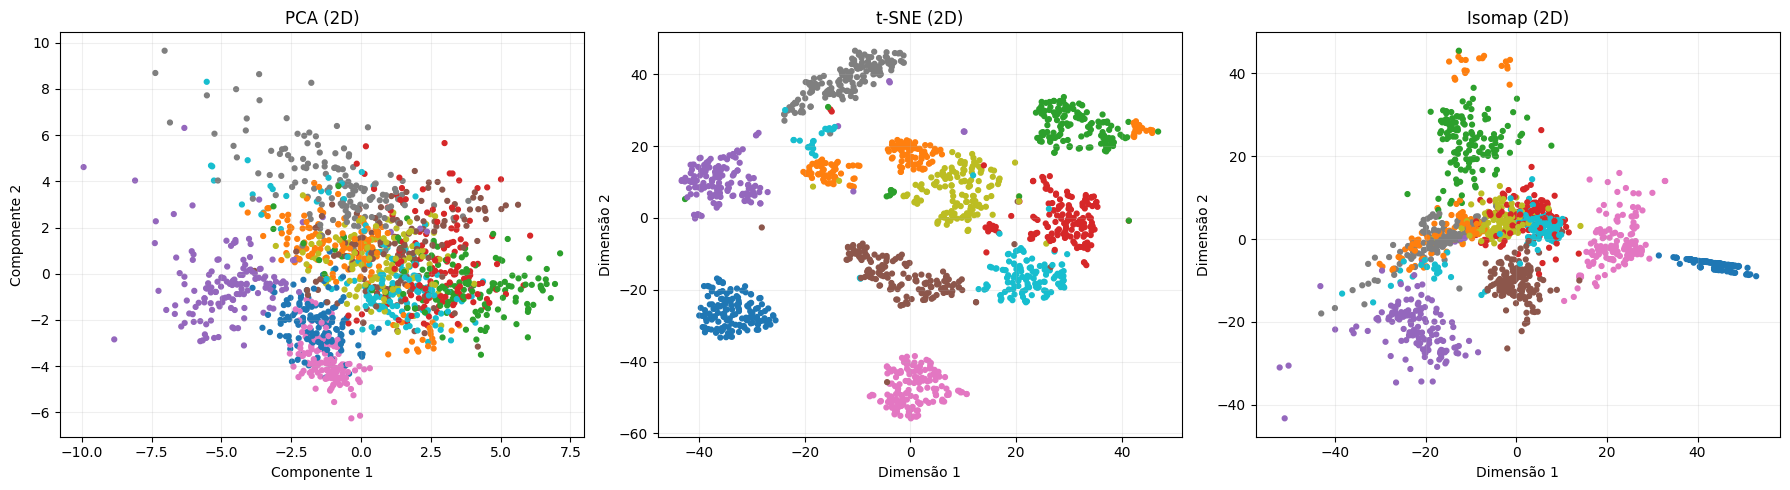

In [71]:
from sklearn.manifold import TSNE, Isomap

pca_2d = PCA(n_components=2)
tsne_2d = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
isomap_2d = Isomap(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_digits_train_scaled)
X_tsne_2d = tsne_2d.fit_transform(X_digits_train_scaled)
X_isomap_2d = isomap_2d.fit_transform(X_digits_train_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_digits_train, cmap='tab10', s=12)
axes[0].set_title('PCA (2D)')
axes[0].set_xlabel('Componente 1')
axes[0].set_ylabel('Componente 2')
axes[0].grid(alpha=0.2)

axes[1].scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], c=y_digits_train, cmap='tab10', s=12)
axes[1].set_title('t-SNE (2D)')
axes[1].set_xlabel('Dimensão 1')
axes[1].set_ylabel('Dimensão 2')
axes[1].grid(alpha=0.2)

axes[2].scatter(X_isomap_2d[:, 0], X_isomap_2d[:, 1], c=y_digits_train, cmap='tab10', s=12)
axes[2].set_title('Isomap (2D)')
axes[2].set_xlabel('Dimensão 1')
axes[2].set_ylabel('Dimensão 2')
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.show()

### <font color='#2D9CDB'>Q25: Com base nos gráficos e na teoria da apostila, comente as diferenças visuais geradas pelos algoritmos na separação das classes, relacionando com suas naturezas matemáticas (linear global, não linear local e não linear global).</font>

`R.:` Visualmente, o PCA tende a separar as classes de forma mais sobreposta porque é um método linear global: ele projeta os dados maximizando variância total, mas não modela curvaturas complexas do espaço original.

`R.:` O t-SNE geralmente mostra grupos mais compactos e bem destacados, pois é não linear local: preserva vizinhanças próximas e destaca estruturas de cluster para visualização, mesmo que distâncias globais fiquem menos fiéis.

`R.:` O Isomap, por ser não linear global, busca preservar distâncias geodésicas na variedade dos dados. Em geral, produz uma estrutura intermediária: melhor que PCA para geometrias não lineares e mais fiel globalmente que métodos puramente locais em vários cenários.

## <font color='green'>**3.7 Seleção de Atributos**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>M. Hopkins, E. Reeber, G. Forman, and J. Suermondt. "Spambase," UCI Machine Learning Repository, 1999. https://doi.org/10.24432/C53G6X</font>

**R.:** O dataset Spambase está no domínio de filtragem de e-mails (segurança da informação e processamento de texto) e tem como objetivo apoiar a construção de modelos capazes de classificar mensagens como spam ou não spam. A base contém atributos numéricos extraídos do conteúdo dos e-mails, como frequências de palavras específicas, frequências de caracteres especiais e medidas relacionadas ao uso de letras maiúsculas, além da variável alvo binária (`Class`) que indica se a mensagem é spam. Por reunir indicadores estatísticos de texto, é amplamente utilizado em tarefas de seleção de atributos e classificação supervisionada.

## <font color='green'>Preparação</font>

In [72]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
ds_spam = fetch_ucirepo(id=94) 
  
# data (as pandas dataframes) 
X_spam = ds_spam.data.features 
y_spam = ds_spam.data.targets 

df_spam = pd.concat([X_spam, y_spam], axis='columns')
df_spam.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


### <font color='#2D9CDB'>Q26: Divida o conjunto de dados em 80% para treinamento e 20% para teste. Em seguida, mostre o número de amostras (linhas) e características (colunas) de cada subconjunto.</font>

In [74]:
from sklearn.model_selection import train_test_split

seed = 42
X_spam_train, X_spam_test, y_spam_train, y_spam_test = train_test_split(
    X_spam, y_spam,
    test_size=0.2,
    random_state=seed
)
print("Número de amostras:", len(X_spam_train))
print("Número de características:", X_spam_train.shape[1])

Número de amostras: 3680
Número de características: 57


### <font color='#2D9CDB'>Q27: Aplique a técnica de Filtro de Baixa Variância (Variance Threshold) utilizando um limiar (threshold) de 0.01. Indique quais features seriam removidas do conjunto de dados por apresentarem variância abaixo deste valor.</spam>

In [60]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.01)
vt.fit(X_spam_train)

selected_features_mask = vt.get_support()
removed_features = X_spam_train.columns[~selected_features_mask]

print(f"Total de features originais: {X_spam_train.shape[1]}")
print(f"Total de features removidas (variância < 0.01): {len(removed_features)}")
print("Features removidas:")
print(removed_features.tolist())


Total de features originais: 57
Total de features removidas (variância < 0.01): 2
Features removidas:
['word_freq_table', 'char_freq_[']


### <font color='#2D9CDB'>Q28: Aplique o Filtro de Multicolinearidade gerando a matriz de correlação entre as features independentes. Identifique os pares de features que possuem uma correlação absoluta maior que 0.80 (∣r∣>0.80). Indique qual(is) feature(s) você removeria para eliminar a redundância.</font>

In [64]:
correlation_matrix = X_spam_train.corr().abs()
high_correlation_pairs = []
threshold = 0.80

for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[1]):
        if correlation_matrix.iloc[i, j] > threshold:
            feature_i = correlation_matrix.index[i]
            feature_j = correlation_matrix.columns[j]
            high_correlation_pairs.append((feature_i, feature_j, correlation_matrix.iloc[i, j]))

print("Pares de features:")
for feature_i, feature_j, corr_value in high_correlation_pairs:
    print(f"{feature_i} - {feature_j}: correlação = {corr_value:.4f}")
    

features_to_remove = set()
for feature_i, feature_j, corr_value in high_correlation_pairs:
    features_to_remove.add(feature_j)

print() 
print("Features para remoção de redundância:")
print(list(features_to_remove))

Pares de features:
word_freq_telnet - word_freq_857: correlação = 0.8223
word_freq_telnet - word_freq_415: correlação = 0.8185
word_freq_857 - word_freq_415: correlação = 0.9943
word_freq_857 - word_freq_direct: correlação = 0.8867
word_freq_415 - word_freq_direct: correlação = 0.8827

Features para remoção de redundância:
['word_freq_direct', 'word_freq_857', 'word_freq_415']


### <font color='#2D9CDB'>Q29: Aplique o filtro de Correlação com o Alvo. Calcule a correlação de Pearson de cada feature com a variável alvo (Class). Indique quais features seriam removidas por possuírem uma correlação absoluta muito baixa, estritamente menor que 0.05 (∣r∣<0.05).</font>

In [81]:
y_spam_train_series = y_spam_train.squeeze()
corr_with_target = X_spam_train.corrwith(y_spam_train_series)

low_corr_features = corr_with_target[corr_with_target.abs() < 0.05].sort_values(key=np.abs)

print('Total de features:', X_spam_train.shape[1])
print(f'Features com |r| < 0.05: {len(low_corr_features)}')
print('\nLista de features removidas por baixa correlação com o alvo:')
print(low_corr_features.index.tolist())

Total de features: 57
Features com |r| < 0.05: 4

Lista de features removidas por baixa correlação com o alvo:
['word_freq_will', 'word_freq_address', 'word_freq_parts', 'word_freq_table']


### <font color='#2D9CDB'>Q28: Aplique a técnica de método de envelopamento RFE (Recursive Feature Elimination) utilizando um modelo de Regressão Logística ou Random Forest. Configure o algoritmo para selecionar apenas as 20 features mais importantes. Indique, de forma resumida, quais features foram descartadas pelo modelo.</font>
- #### <font color='#2D9CDB'>Utilize o modelo de [Regressão Logística](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) (`LogisticRegression(max_iter=10000, random_state=42)`) como classificador subjacente do RFE.</font>

In [82]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=10000, random_state=42)
rfe_selector = RFE(estimator=log_reg, n_features_to_select=20)
rfe_selector.fit(X_spam_train, y_spam_train.squeeze())

selected_features_rfe = X_spam_train.columns[rfe_selector.support_]
discarded_features_rfe = X_spam_train.columns[~rfe_selector.support_]

print(f'Total de features originais: {X_spam_train.shape[1]}')
print(f'Features selecionadas (20): {len(selected_features_rfe)}')
print(f'Features descartadas: {len(discarded_features_rfe)}')
print('\nFeatures descartadas pelo RFE:')
print(discarded_features_rfe.tolist())

Total de features originais: 57
Features selecionadas (20): 20
Features descartadas: 37

Features descartadas pelo RFE:
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_internet', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_email', 'word_freq_you', 'word_freq_your', 'word_freq_font', 'word_freq_money', 'word_freq_650', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_direct', 'word_freq_original', 'word_freq_re', 'word_freq_table', 'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!', 'capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total']


### <font color='#2D9CDB'>Q30) O algoritmo RFE não apenas seleciona as variáveis, mas cria um ranking de importância para todas elas.</font>
- #### <font color='#2D9CDB'>a) Utilizando o atributo `.ranking_` do seletor ajustado na questão anterior, construa um DataFrame que mostre o nome das features originais lado a lado com sua posição no ranking. Ordene os resultados para exibir as features selecionadas (rank 1) no topo da tabela.</font>
- #### <font color='#2D9CDB'>b) Analisando o ranking, quais "termos" (palavras, símbolos de pontuação ou métricas de texto) o modelo considerou como os mais importantes para a detecção de spam (Rank 1)?</font>
- #### <font color='#2D9CDB'>c) Analisando o ranking, quais termos demonstraram ter o menor significado preditivo, sendo eliminados nas primeiras iterações (piores posições no ranking)?</font>

In [83]:
ranking_df = pd.DataFrame({
    'feature': X_spam_train.columns,
    'rank': rfe_selector.ranking_
}).sort_values(['rank', 'feature']).reset_index(drop=True)

print('Ranking completo (topo da tabela):')
print(ranking_df.head(30))

rank1_features = ranking_df[ranking_df['rank'] == 1]['feature'].tolist()
worst_rank = ranking_df['rank'].max()
worst_features = ranking_df[ranking_df['rank'] == worst_rank]['feature'].tolist()

print('\nFeatures consideradas mais importantes (rank 1):')
print(rank1_features)

print(f'\nPiores features no ranking (rank {worst_rank}):')
print(worst_features)

Ranking completo (topo da tabela):
                 feature  rank
0            char_freq_#     1
1            char_freq_$     1
2          word_freq_000     1
3           word_freq_85     1
4    word_freq_addresses     1
5     word_freq_business     1
6   word_freq_conference     1
7       word_freq_credit     1
8           word_freq_cs     1
9          word_freq_edu     1
10        word_freq_free     1
11      word_freq_george     1
12          word_freq_hp     1
13         word_freq_hpl     1
14         word_freq_lab     1
15     word_freq_meeting     1
16       word_freq_order     1
17          word_freq_pm     1
18     word_freq_project     1
19      word_freq_remove     1
20          word_freq_3d     2
21        word_freq_data     3
22    word_freq_original     4
23        word_freq_over     5
24       word_freq_table     6
25  word_freq_technology     7
26       word_freq_parts     8
27           char_freq_;     9
28       word_freq_money    10
29         word_freq_our    11

Fea

`R.:` As features em **rank 1** representam os termos/sinais que mais contribuíram para a detecção de spam no modelo RFE com Regressão Logística, e foram listadas na saída da célula anterior.

`R.:` Em geral, termos associados a linguagem promocional, sinais monetários e padrões de formatação tendem a aparecer entre os mais relevantes nesse tipo de dataset.

`R.:` Já as features nas piores posições de ranking (maior valor de rank) foram as menos úteis para predição e, por isso, eliminadas mais cedo no processo recursivo de seleção. Elas também foram exibidas pela célula anterior.